# Model experiments and lifecycle
Run `make train` first. Training lives in `src/models/train.py`; this notebook inspects **actual MLflow-linked validation results** without retraining or opening the test set.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'configs').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from src.utils.config import load_config, get_path
from src.features.build_features import FEATURES
from src.models.common import read_dataset
cfg = load_config()
ARTIFACTS = get_path(cfg, 'artifacts')


## Candidate estimators
A mean baseline, scaled Ridge, Random Forest and histogram gradient boosting. Early stopping is disabled to avoid a random internal validation split. Fixed configurations keep this university comparison small and reproducible.

In [2]:
from src.models.estimators import candidates
for name, estimator in candidates(cfg).items():
    display({name: estimator.get_params()})

{'dummy_mean': {'estimator__constant': None,
  'estimator__quantile': None,
  'estimator__strategy': 'mean',
  'estimator': DummyRegressor()}}

{'ridge': {'estimator__memory': None,
  'estimator__steps': [('standardscaler', StandardScaler()),
   ('ridge', Ridge(alpha=10.0))],
  'estimator__transform_input': None,
  'estimator__verbose': False,
  'estimator__standardscaler': StandardScaler(),
  'estimator__ridge': Ridge(alpha=10.0),
  'estimator__standardscaler__copy': True,
  'estimator__standardscaler__with_mean': True,
  'estimator__standardscaler__with_std': True,
  'estimator__ridge__alpha': 10.0,
  'estimator__ridge__copy_X': True,
  'estimator__ridge__fit_intercept': True,
  'estimator__ridge__max_iter': None,
  'estimator__ridge__positive': False,
  'estimator__ridge__random_state': None,
  'estimator__ridge__solver': 'auto',
  'estimator__ridge__tol': 0.0001,
  'estimator': Pipeline(steps=[('standardscaler', StandardScaler()),
                  ('ridge', Ridge(alpha=10.0))])}}

{'random_forest': {'estimator__bootstrap': True,
  'estimator__ccp_alpha': 0.0,
  'estimator__criterion': 'squared_error',
  'estimator__max_depth': None,
  'estimator__max_features': 1.0,
  'estimator__max_leaf_nodes': None,
  'estimator__max_samples': None,
  'estimator__min_impurity_decrease': 0.0,
  'estimator__min_samples_leaf': 4,
  'estimator__min_samples_split': 2,
  'estimator__min_weight_fraction_leaf': 0.0,
  'estimator__monotonic_cst': None,
  'estimator__n_estimators': 160,
  'estimator__n_jobs': 1,
  'estimator__oob_score': False,
  'estimator__random_state': 42,
  'estimator__verbose': 0,
  'estimator__warm_start': False,
  'estimator': RandomForestRegressor(min_samples_leaf=4, n_estimators=160, n_jobs=1,
                        random_state=42)}}

{'gradient_boosting': {'estimator__categorical_features': 'from_dtype',
  'estimator__early_stopping': False,
  'estimator__interaction_cst': None,
  'estimator__l2_regularization': 0.0,
  'estimator__learning_rate': 0.05,
  'estimator__loss': 'squared_error',
  'estimator__max_bins': 255,
  'estimator__max_depth': None,
  'estimator__max_features': 1.0,
  'estimator__max_iter': 200,
  'estimator__max_leaf_nodes': 15,
  'estimator__min_samples_leaf': 20,
  'estimator__monotonic_cst': None,
  'estimator__n_iter_no_change': 10,
  'estimator__quantile': None,
  'estimator__random_state': 42,
  'estimator__scoring': 'loss',
  'estimator__tol': 1e-07,
  'estimator__validation_fraction': 0.1,
  'estimator__verbose': 0,
  'estimator__warm_start': False,
  'estimator': HistGradientBoostingRegressor(early_stopping=False, learning_rate=0.05,
                                max_iter=200, max_leaf_nodes=15, random_state=42)}}

## Chronological selection
Scalers are fitted within estimator pipelines on training data only. All candidates use the same features and clipping rule. Validation RMSE determines the winner; test metrics cannot enter this table.

,model,mae,rmse,r2,run_id
0,gradient_boosting,0.128789,0.170564,0.617846,9fb54e39f255405ba61662ffaed348d5
1,random_forest,0.134563,0.177395,0.586623,53a28070c66c4acb8fd37524f3cc7268
2,ridge,0.164718,0.203292,0.457120,bb40b573438d4934a2fd98c27589a438
3,dummy_mean,0.293414,0.326490,-0.400239,f937f41a40c145179c12ac8e7e182f34


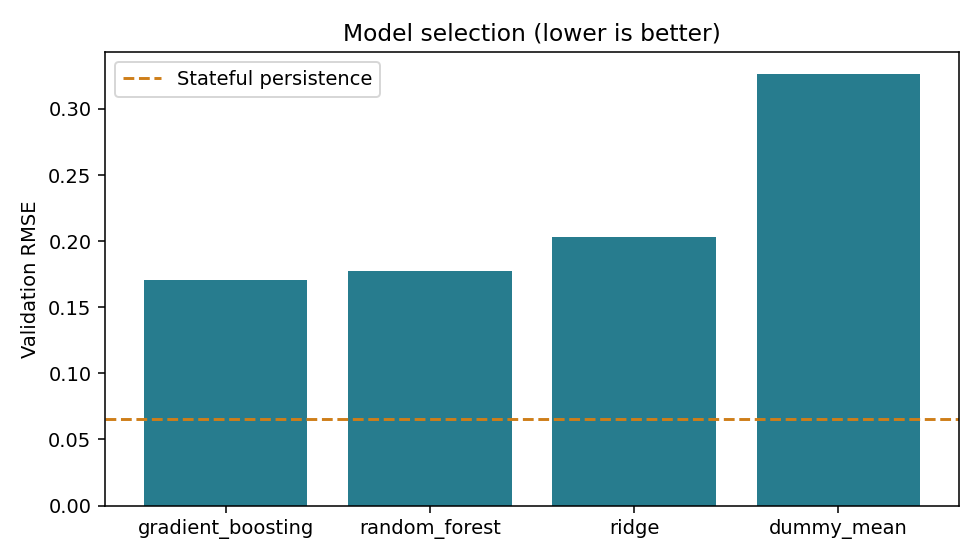

{'mae': 0.034439236224455744,
 'r2': 0.9437222942783051,
 'rmse': 0.06545412803782129}

In [3]:
comparison = pd.read_csv(ARTIFACTS / 'model_comparison.csv')
display(comparison)
display(Image(filename=str(ARTIFACTS / 'model_comparison.png')))
display(json.loads((ARTIFACTS / 'validation_persistence.json').read_text()))

## Selected candidate
The selected estimator is refitted on training plus validation data. Persistence has access to the full-history modeled state, so it is a valuable but information-advantaged comparator.

In [4]:
selection = json.loads((ARTIFACTS / 'selection.json').read_text())
display(selection)
assert selection['test_used_for_selection'] is False

{'model_file': 'v3-2771746c21f7/model.joblib',
 'model_type': 'gradient_boosting',
 'model_version': 'v3-2771746c21f7',
 'persistence': {'mae': 0.034439236224455744,
  'r2': 0.9437222942783051,
  'rmse': 0.06545412803782129},
 'registry_version': '3',
 'sha256': '777ca5e54a876623bb1aeb6cb52157ceb16357e0c17fefd95537c85d2324479a',
 'test_used_for_selection': False,
 'validation_metrics': {'mae': 0.12878910487161976,
  'r2': 0.6178461152666185,
  'rmse': 0.17056424214821458}}

## Inspect MLflow runs
Launch `make mlflow` and open http://localhost:5000. Each run includes parameters, feature contract, dataset hash, validation metrics, plots and estimator. Candidate/production aliases demonstrate promotion without paid services.

In [5]:
from src.models.common import setup_tracking
import mlflow
setup_tracking(cfg)
runs = mlflow.search_runs(experiment_names=[cfg['tracking']['experiment']])
columns = [c for c in ['run_id', 'tags.mlflow.runName', 'metrics.validation_rmse', 'metrics.validation_mae'] if c in runs]
display(runs[columns])

2026-09-07 19:02:09,490 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas


2026-09-07 19:02:09,491 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables


2026-09-07 19:02:09,492 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types


2026-09-07 19:02:09,493 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints


2026-09-07 19:02:09,494 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults


...

INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


INFO  [alembic.runtime.migration] Context impl SQLiteImpl.


INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


,run_id,tags.mlflow.runName,metrics.validation_rmse,metrics.validation_mae
0,6ab3d0b26cb742fc93db1737b0fee72b,candidate-gradient_boosting-2771746c,NaN,NaN
1,9fb54e39f255405ba61662ffaed348d5,validation-gradient_boosting-2771746c,0.170564,0.128789
2,53a28070c66c4acb8fd37524f3cc7268,validation-random_forest-2771746c,0.177395,0.134563
3,bb40b573438d4934a2fd98c27589a438,validation-ridge-2771746c,0.203292,0.164718
4,f937f41a40c145179c12ac8e7e182f34,validation-dummy_mean-2771746c,0.326490,0.293414
5,8dbfe82891454b9b9f0491775af1be5f,candidate-gradient_boosting-2771746c,NaN,NaN
6,292c084c1cf840d8adcd7ed0f54fb4fa,validation-gradient_boosting-2771746c,0.170564,0.128789
7,24255cfeb93940e08e30d674c1a8bccf,validation-random_forest-2771746c,0.177395,0.134563
8,5fc92861b3e249faaa5e4a938135b32b,validation-ridge-2771746c,0.203292,0.164718
9,0acf43f98b664331b9bcc05ac1646a86,validation-dummy_mean-2771746c,0.326490,0.293414


## Final evaluation and deployment
After selection run `make evaluate promote reports`. Frozen test metrics are published separately in `artifacts/evaluation/<version>/test_metrics.json`. Do not adjust models based on this test; further research requires a new holdout period. Then run `make api`, `make demo-request`, and `make monitor`.